In [1]:
import numpy as np
from numpy import linalg as LA
import scipy
import math
import scipy.linalg as la
from scipy.sparse.linalg import eigsh, eigs, expm_multiply
from scipy.linalg import expm
import matplotlib.pyplot as plt
import multiprocessing as mp
import random, math
from scipy import stats
from scipy.ndimage import gaussian_filter1d
import operator
from scipy.optimize import curve_fit 
from matplotlib.colors import LogNorm
from scipy import interpolate
from scipy.interpolate import interp2d
from scipy.interpolate import interp1d
from scipy.special import gamma, factorial
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib import colors
from matplotlib import rc
rc('text',usetex=True)
import matplotlib.ticker as tick
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.optimize import minimize
from scipy.optimize import dual_annealing, basinhopping, differential_evolution

In [14]:
Gap_200 = np.loadtxt("Gap_vs_T_dt=0.001_N=200_chi_max=256_a=0.80_h=0.00_.dat")
Gap_250 = np.loadtxt("Gap_vs_T_dt=0.001_N=250_chi_max=256_a=0.80_h=0.00_.dat")
Gap_300 = np.loadtxt("Gap_vs_T_dt=0.001_N=300_chi_max=256_a=0.80_h=0.00_.dat")
Gap_350 = np.loadtxt("Gap_vs_T_dt=0.001_N=350_chi_max=256_a=0.80_h=0.00_.dat")
Gap_400 = np.loadtxt("Gap_vs_T_dt=0.001_N=400_chi_max=256_a=0.80_h=0.00_.dat")

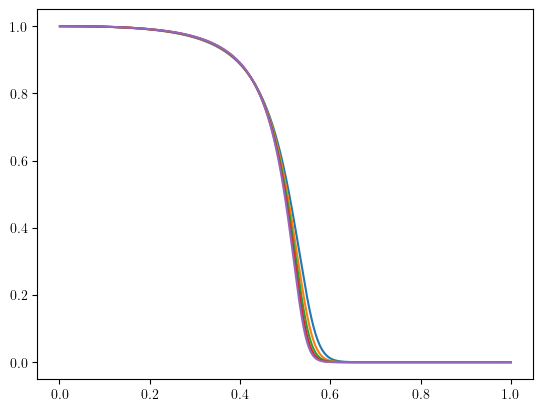

In [15]:
m = 0
n = 1000
plt.plot(Gap_200[m:n,0],Gap_200[m:n,1])
plt.plot(Gap_250[m:n,0],Gap_250[m:n,1])
plt.plot(Gap_300[m:n,0],Gap_300[m:n,1])
plt.plot(Gap_350[m:n,0],Gap_350[m:n,1])
plt.plot(Gap_400[m:n,0],Gap_400[m:n,1])

plt.show()

In [16]:
#define rescaled variables
def YL(y,L,a):
    return y*L**a

def XL(x,L,xc,b):
    return (x-xc)*L**b

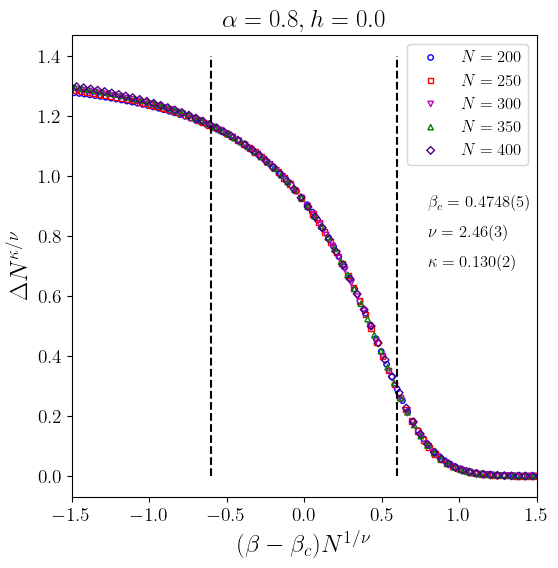

In [19]:
fig, ax = plt.subplots(figsize=(6,6))

xc,a,b = [0.47477942, 0.05291583, 0.40489991]

n = 4

ax.scatter(XL(Gap_200[:,0],200,xc,b)[::n],YL(Gap_200[:,1],200,a)[::n],s=15,marker='o', facecolors='none',edgecolor = 'b',label=r"$N = 200$")
ax.scatter(XL(Gap_200[:,0],250,xc,b)[::n],YL(Gap_250[:,1],250,a)[::n],s=15,marker='s', facecolors='none',edgecolor = 'r',label=r"$N = 250$")
ax.scatter(XL(Gap_200[:,0],300,xc,b)[::n],YL(Gap_300[:,1],300,a)[::n],s=15,marker='v', facecolors='none',edgecolor = 'm',label=r"$N = 300$")
ax.scatter(XL(Gap_200[:,0],350,xc,b)[::n],YL(Gap_350[:,1],350,a)[::n],s=15,marker='^', facecolors='none',edgecolor = 'g',label=r"$N = 350$")
ax.scatter(XL(Gap_200[:,0],400,xc,b)[::n],YL(Gap_400[:,1],400,a)[::n],s=15,marker='D', facecolors='none',edgecolor = 'indigo',label=r"$N = 400$")

ax.plot([0.6,0.6],[0.0,1.4],'--',color='k',linewidth=1.5)
ax.plot([-0.6,-0.6],[0.0,1.4],'--',color='k',linewidth=1.5)

plt.text(0.8, 0.9,r'$\beta_c = 0.4748(5)$', fontsize = 12)
plt.text(0.8, 0.8,r'$\nu = 2.46(3)$', fontsize = 12)
plt.text(0.8, 0.7,r'$\kappa = 0.130(2)$', fontsize = 12)

 

ax.set_title(r'$\alpha = 0.8,h = 0.0$',fontsize =18,fontweight='bold')
ax.set_xlabel(r'$(\beta-\beta_c)N^{1/\nu}$',fontsize =18,fontweight='bold')
ax.set_ylabel(r'$\Delta N^{\kappa/\nu}$',fontsize =18,fontweight='bold')

plt.xlim(-1.5,1.5)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
ax.legend(loc='upper right',fontsize=12)

plt.savefig('rescaled_Schmidt_gap_a=0.8_h=0.0.pdf',bbox_inches="tight")

plt.show()

In [110]:
nu = 1/0.40503335
nu

2.468932496546272

In [112]:
k = 0.08198583*nu
k

0.2024174799433182

In [266]:
1.8, 0.0

main = [0.73572705, 0.09001034, 0.42725894]

crit_list = np.array([[0.73787782, 0.09179626, 0.42232139],
[0.73539974, 0.08977752, 0.42768387],
[0.73587236, 0.09020058, 0.4270706 ],
[0.73572706, 0.09001307, 0.42725894],
[0.73627165, 0.09259285, 0.43614959]])

nu = 1/main[2]
k = main[1]*nu
print(nu,k)

2.3405010554021413 0.21066929576710555


In [276]:
1.8,0.3

main = [0.80065894, 0.11076817, 0.42508895]

crit_list = np.array([[0.801927,   0.11122831, 0.41718994],
[0.80088411, 0.11216543, 0.42933388],
[0.80060215, 0.11041226, 0.4243604 ],
[0.80082318, 0.11113369, 0.42505571],
[0.8003711,  0.11204262, 0.4321565 ]])
nu = 1/main[2]
k = main[1]*nu
print(nu,k)

2.3524488227699165 0.260576451116878


In [235]:
0.8,0.0

main = [0.47477942, 0.05291583, 0.40489991]

crit_list = np.array([[0.47554154, 0.05254926, 0.3915374 ],
[0.47500029, 0.05390321, 0.40821023],
[0.47436576, 0.0517588,  0.40076932],
[0.47458263, 0.05217961, 0.40247905],
[0.47393812, 0.05240537, 0.40837876]])

nu = 1/main[2]
k = main[1]*nu
print(nu,k)

2.46974616516956 0.13068866821926436


In [249]:
0.8,0.3

main = [0.47756269, 0.05307781, 0.40431827]

crit_list = np.array([[0.47885598, 0.05425761, 0.39474012],
[0.4779392,  0.05442141, 0.40945442],
[0.47764919, 0.05322547, 0.40434591],
[0.4782315,  0.05479686, 0.40893973],
[0.47735611, 0.05382397, 0.41218668]])

nu = 1/main[2]
k = main[1]*nu
print(nu,k)

2.4732990670938517 0.1312772979563847


In [277]:
xc_list = crit_list[:,0]
a_list = crit_list[:,1]
b_list = crit_list[:,2]
nu_list = 1/b_list
k_list = a_list*nu_list

In [278]:
def jackknife_se(vals):
    n = vals.size
    mean_jk = vals.mean()
    var_jk  = 1/n * np.sum((vals - mean_jk)**2)
    return np.sqrt(var_jk), mean_jk

In [279]:
err,bias = jackknife_se(xc_list)
print(err)
print(bias)

0.0005342320968792279
0.8009215080000001


In [280]:
err,bias = jackknife_se(nu_list)
print(err)
print(bias)

0.02824079716154395
2.3498552360656246


In [281]:
err,bias = jackknife_se(k_list)
print(err)
print(bias)

0.002553833859007087
0.26175470797032874
